# 00 — Local Setup and Data Validation

Run this notebook first, before any other notebook or training run.

**Steps covered:**
1. Validate project paths and directory structure
2. Clean labels and build `metadata.csv` (if not already present)
3. Validate metadata CSV contents and label distribution
4. Generate train/val/test splits (if not already done)
5. Validate split label mix
6. Render all PDFs to `data/rendered_pages/`
7. Spot-check rendered images

## 0. Configuration

Paths are resolved relative to the repository root. No changes are needed if you are running from the `notebooks/` directory.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR     = PROJECT_ROOT / "data"
RENDERED_DIR = DATA_DIR / "rendered_pages"
SPLITS_DIR   = DATA_DIR / "splits"
METADATA_CSV = DATA_DIR / "metadata.csv"

# Source PDF directories (Hebrew-named subdirs under data/)
EXCLUDE_DIRS = {"rendered_pages", "splits"}

print(f"Project root  : {PROJECT_ROOT}")
print(f"Data dir      : {DATA_DIR}")
print(f"Rendered dir  : {RENDERED_DIR}")
print(f"Metadata CSV  : {METADATA_CSV}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Project root  : /Users/idan/projects/sandbox/for_tal
Data dir      : /Users/idan/projects/sandbox/for_tal/data
Rendered dir  : /Users/idan/projects/sandbox/for_tal/data/rendered_pages
Metadata CSV  : /Users/idan/projects/sandbox/for_tal/data/metadata.csv
Data dir exists: True


## 1. Validate Directory Structure

In [2]:
import os

# Verify data directory exists and list top-level contents
if not DATA_DIR.exists():
    print(f"ERROR: data directory not found at {DATA_DIR}")
    print("Ensure the repository is cloned and that the data/ folder is present.")
else:
    entries = [p for p in DATA_DIR.iterdir()]
    print(f"data/ exists with {len(entries)} entries:")
    for e in sorted(entries):
        kind = "dir" if e.is_dir() else "file"
        print(f"  [{kind}] {e.name}")

# Check for source PDF subdirectories
pdf_subdirs = [d for d in DATA_DIR.iterdir() if d.is_dir() and d.name not in EXCLUDE_DIRS]
print(f"\nSource PDF subdirectories found: {len(pdf_subdirs)}")
for d in pdf_subdirs:
    n_pdfs = len(list(d.rglob("*.pdf")))
    print(f"  {d.name}: {n_pdfs} PDFs")

data/ exists with 12 entries:
  [file] .DS_Store
  [dir] handwritten
  [file] handwritten.xlsx
  [file] labels_binary.csv
  [file] labels_binary_clean.csv
  [file] labels_rubric.csv
  [file] metadata.csv
  [dir] regular_forms
  [file] regular_forms.xlsx
  [dir] rendered_pages
  [file] rubric_checkpoint.jsonl
  [dir] splits

Source PDF subdirectories found: 2
  regular_forms: 634 PDFs
  handwritten: 386 PDFs


## 2. Build Metadata CSV (if not already present)

`scripts/clean_labels.py` reads `data/labels_binary.csv` and produces:
- `data/labels_binary_clean.csv` — cleaned binary labels
- `data/metadata.csv` — master index with all required columns

In [3]:
import subprocess

labels_binary = DATA_DIR / "labels_binary.csv"
labels_clean  = DATA_DIR / "labels_binary_clean.csv"

if METADATA_CSV.exists() and labels_clean.exists():
    print("metadata.csv and labels_binary_clean.csv already exist — skipping clean_labels.py")
elif not labels_binary.exists():
    print(f"ERROR: {labels_binary} not found.")
    print("Place labels_binary.csv in the data/ directory before running this notebook.")
else:
    print("Running scripts/clean_labels.py ...")
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "scripts" / "clean_labels.py"),
         "--input", str(labels_binary),
         "--out-dir", str(DATA_DIR)],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)
    else:
        print("clean_labels.py completed successfully.")

metadata.csv and labels_binary_clean.csv already exist — skipping clean_labels.py


## 3. Validate Metadata CSV

In [4]:
import pandas as pd

if not METADATA_CSV.exists():
    print(f"ERROR: metadata.csv not found at {METADATA_CSV}")
    print("Run the cell above (clean_labels.py) to generate it.")
else:
    df = pd.read_csv(METADATA_CSV)
    print(f"metadata.csv shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nLabel distribution:")
    print(df["label_binary"].value_counts().rename({0: "safe (0)", 1: "risky (1)"}))
    print(f"\nInstitution distribution:")
    print(df["institution"].value_counts())
    if "split" in df.columns:
        assigned = df["split"].notna() & (df["split"] != "")
        print(f"\nRows with split assigned: {assigned.sum()} / {len(df)}")
    # Check for rubric annotation
    rubric_done = (df["D"] != -1).sum()
    print(f"\nRubric annotated rows: {rubric_done} / {len(df)}")
    if rubric_done == 0:
        print("NOTE: D/H/S/L rubric scores not yet populated. Stub values (-1) are fine for binary training.")

metadata.csv shape: (1014, 13)
Columns: ['file_path', 'page_num', 'institution', 'template_family', 'label_binary', 'D', 'H', 'S', 'L', 'risk_score', 'split', 'drive_link', 'drive_id']

Label distribution:
label_binary
safe (0)     634
risky (1)    380
Name: count, dtype: int64

Institution distribution:
institution
regular_docs      634
questionnaires    380
Name: count, dtype: int64

Rows with split assigned: 1014 / 1014

Rubric annotated rows: 1014 / 1014


## 4. Validate PDF Count

In [5]:
EXPECTED_PDF_COUNT = 1014

all_pdfs = []
for subdir in pdf_subdirs:
    all_pdfs.extend(list(subdir.rglob("*.pdf")))

print(f"Total PDFs found locally: {len(all_pdfs)} / {EXPECTED_PDF_COUNT} expected")
if len(all_pdfs) < EXPECTED_PDF_COUNT:
    print(f"WARNING: {EXPECTED_PDF_COUNT - len(all_pdfs)} PDFs appear to be missing.")
    print("Check that data subdirectories are fully populated.")
else:
    print("PDF count OK")

for subdir in pdf_subdirs:
    n = len(list(subdir.rglob("*.pdf")))
    print(f"  {subdir.name}: {n} PDFs")

Total PDFs found locally: 1020 / 1014 expected
PDF count OK
  regular_forms: 634 PDFs
  handwritten: 386 PDFs


## 5. Generate Splits (if not already done)

In [6]:
import yaml
from src.data.splits import create_grouped_splits, save_splits

# Load config to get split settings
with open(PROJECT_ROOT / "configs" / "baseline.yaml") as f:
    cfg = yaml.safe_load(f)

expected_splits = ["train.csv", "val.csv", "test.csv"]
splits_present = all((SPLITS_DIR / s).exists() for s in expected_splits)

if splits_present:
    print("Splits already exist:")
    for s in expected_splits:
        split_df = pd.read_csv(SPLITS_DIR / s)
        print(f"  {s}: {len(split_df)} rows")
else:
    print("Splits not found — generating now...")
    metadata_df = pd.read_csv(METADATA_CSV)
    group_col = cfg["splits"]["group_col"]  # template_family
    ratios = {
        "train": cfg["splits"]["train_ratio"],
        "val":   cfg["splits"]["val_ratio"],
        "test":  cfg["splits"]["test_ratio"],
    }
    metadata_df = create_grouped_splits(metadata_df, group_col=group_col, ratios=ratios)
    SPLITS_DIR.mkdir(parents=True, exist_ok=True)
    save_splits(metadata_df, output_dir=str(SPLITS_DIR))

    # Persist updated metadata with split column
    metadata_df.to_csv(METADATA_CSV, index=False)
    print("Splits generated and metadata.csv updated.")
    for s in expected_splits:
        sdf = pd.read_csv(SPLITS_DIR / s)
        print(f"  {s}: {len(sdf)} rows")

Splits already exist:
  train.csv: 710 rows
  val.csv: 152 rows
  test.csv: 152 rows


## 5b. Validate Split Label Mix

Checks that each split (train / val / test) contains **both** label classes and that
no split is dominated by a single class.

**Why this matters:** `institution` is perfectly correlated with label in the current
dataset (`regular_docs` = safe, `questionnaires` = risky). If `institution` were used
as the grouping key, one entire split could end up with only one class.  
The configs use `template_family` instead, but we verify the result here regardless.

Split         N    Safe (0)   Risky (1)    Risky%  Status
train       710         444         266    37.5%  OK
val         152          95          57    37.5%  OK
test        152          95          57    37.5%  OK

Split mix: PASS — all splits contain both classes above threshold.

Institution distribution per split:
institution  questionnaires  regular_docs
split                                    
test                     57            95
train                   266           444
val                      57            95


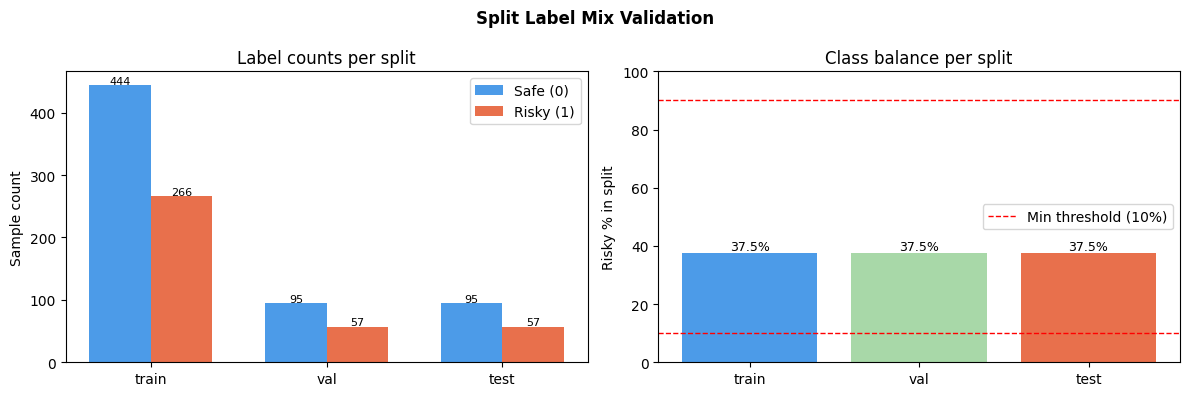

In [7]:
import matplotlib.pyplot as plt
import numpy as np

split_names = ["train", "val", "test"]
EXPECTED_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}
MIN_MINORITY_FRACTION = 0.10   # flag if any class is below 10% in a split

all_ok = True
split_stats = []

print("=" * 60)
print(f"{'Split':<8} {'N':>6}  {'Safe (0)':>10}  {'Risky (1)':>10}  {'Risky%':>8}  {'Status'}")
print("=" * 60)

for name in split_names:
    csv_path = SPLITS_DIR / f"{name}.csv"
    if not csv_path.exists():
        print(f"{name:<8}  NOT FOUND — run cell 5 first")
        all_ok = False
        continue

    sdf = pd.read_csv(csv_path)
    n = len(sdf)
    n_safe  = (sdf["label_binary"] == 0).sum()
    n_risky = (sdf["label_binary"] == 1).sum()
    risky_pct = n_risky / n if n > 0 else 0

    issues = []
    if n_safe == 0:
        issues.append("NO SAFE SAMPLES")
    if n_risky == 0:
        issues.append("NO RISKY SAMPLES")
    if risky_pct < MIN_MINORITY_FRACTION:
        issues.append(f"risky < {MIN_MINORITY_FRACTION:.0%}")
    if risky_pct > (1 - MIN_MINORITY_FRACTION):
        issues.append(f"safe < {MIN_MINORITY_FRACTION:.0%}")

    status = "OK" if not issues else "WARNING: " + ", ".join(issues)
    if issues:
        all_ok = False

    print(f"{name:<8} {n:>6}  {n_safe:>10}  {n_risky:>10}  {risky_pct:>7.1%}  {status}")
    split_stats.append({"name": name, "n": n, "safe": n_safe, "risky": n_risky, "risky_pct": risky_pct})

print("=" * 60)

if all_ok:
    print("\nSplit mix: PASS — all splits contain both classes above threshold.")
else:
    print("\nSplit mix: FAIL — review warnings above before training.")
    print("Consider switching configs/baseline.yaml splits.strategy to 'kfold'")
    print("or manually adjusting the group_col to better balance classes.")

# --- Institution breakdown per split ---
print("\nInstitution distribution per split:")
meta_split_df = pd.read_csv(METADATA_CSV)
if "split" in meta_split_df.columns and meta_split_df["split"].notna().any():
    cross = pd.crosstab(meta_split_df["split"], meta_split_df["institution"])
    print(cross.to_string())
else:
    print("  'split' column not yet populated in metadata.csv — run cell 5 first.")

# --- Bar chart ---
if split_stats:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Absolute counts
    ax = axes[0]
    x = np.arange(len(split_stats))
    width = 0.35
    safe_vals  = [s["safe"]  for s in split_stats]
    risky_vals = [s["risky"] for s in split_stats]
    ax.bar(x - width/2, safe_vals,  width, label="Safe (0)",  color="#4C9BE8")
    ax.bar(x + width/2, risky_vals, width, label="Risky (1)", color="#E8704C")
    ax.set_xticks(x)
    ax.set_xticklabels([s["name"] for s in split_stats])
    ax.set_ylabel("Sample count")
    ax.set_title("Label counts per split")
    ax.legend()
    for i, (sv, rv) in enumerate(zip(safe_vals, risky_vals)):
        ax.text(i - width/2, sv + 2, str(sv), ha="center", fontsize=8)
        ax.text(i + width/2, rv + 2, str(rv), ha="center", fontsize=8)

    # Risky fraction
    ax2 = axes[1]
    risky_pcts = [s["risky_pct"] * 100 for s in split_stats]
    bars = ax2.bar([s["name"] for s in split_stats], risky_pcts, color=["#4C9BE8", "#A8D8A8", "#E8704C"])
    ax2.axhline(MIN_MINORITY_FRACTION * 100, color="red", linestyle="--", linewidth=1, label=f"Min threshold ({MIN_MINORITY_FRACTION:.0%})")
    ax2.axhline((1 - MIN_MINORITY_FRACTION) * 100, color="red", linestyle="--", linewidth=1)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Risky % in split")
    ax2.set_title("Class balance per split")
    ax2.legend()
    for bar, pct in zip(bars, risky_pcts):
        ax2.text(bar.get_x() + bar.get_width()/2, pct + 1, f"{pct:.1f}%", ha="center", fontsize=9)

    plt.suptitle("Split Label Mix Validation", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 6. Render PDFs to Images

Renders all PDFs found under `data/` subdirectories to grayscale PNGs at 150 DPI.  
Output is written to `data/rendered_pages/`.  
Re-running is safe — existing images are skipped (`skip_existing=True`).

In [8]:
from src.data.render_pdf import render_all

RENDERED_DIR.mkdir(parents=True, exist_ok=True)

all_results = []
for subdir in pdf_subdirs:
    print(f"Rendering PDFs from: {subdir.name} ...")
    results = render_all(
        pdf_dir=str(subdir),
        output_dir=str(RENDERED_DIR),
        dpi=150,
        grayscale=True,
        target_size=(224, 224),
        skip_existing=True,
    )
    all_results.extend(results)

status_counts = {}
for r in all_results:
    s = r["status"]
    status_counts[s] = status_counts.get(s, 0) + 1

print(f"\nRendering complete: {status_counts}")

rendered_files = list(RENDERED_DIR.glob("*.png"))
print(f"Total rendered images: {len(rendered_files)}")

Rendering PDFs from: regular_forms ...
Rendering PDFs from: handwritten ...

Rendering complete: {'skipped': 1020}
Total rendered images: 1020


## 7. Spot-Check Rendered Images

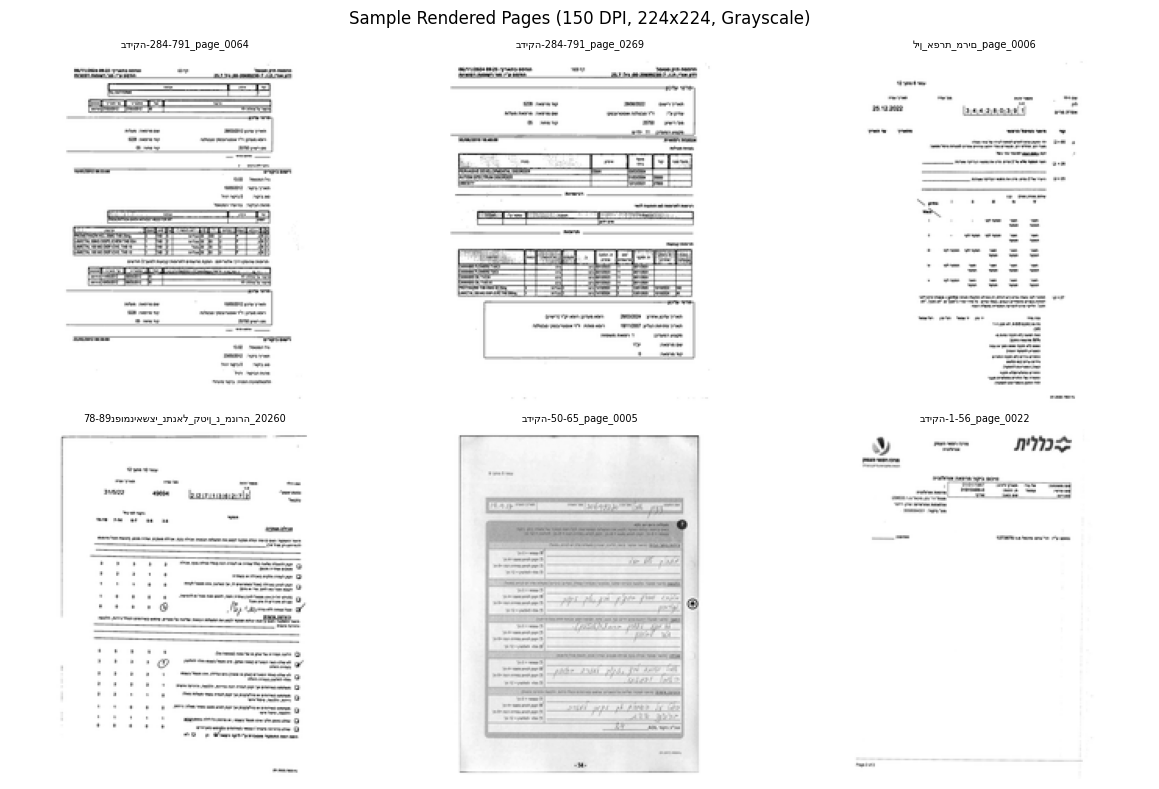

In [9]:
import random
from PIL import Image

rendered_files = list(RENDERED_DIR.glob("*.png"))

if not rendered_files:
    print("No rendered images found — run cell 6 first.")
else:
    sample = random.sample(rendered_files, min(6, len(rendered_files)))
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, png_path in zip(axes.flat, sample):
        img = Image.open(png_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(Path(png_path).stem[:40], fontsize=7)
        ax.axis("off")
    # hide any unused axes
    for ax in axes.flat[len(sample):]:
        ax.set_visible(False)
    plt.suptitle("Sample Rendered Pages (150 DPI, 224x224, Grayscale)")
    plt.tight_layout()
    plt.show()

## 8. Setup Complete — Next Steps

| Step | Notebook / Script |
|------|-------------------|
| Data audit | `01_data_audit.ipynb` |
| Rendering quality check | `02_rendering_checks.ipynb` |
| Label consistency | `03_label_consistency.ipynb` |
| Baseline training (ResNet/ViT) | `04_baseline_training.ipynb` |
| DiT fine-tuning | `05_dit_training.ipynb` |
| Calibration & threshold selection | `06_calibration_eval.ipynb` |

**Before training, complete:**
- [ ] Populate D/H/S/L rubric scores in `metadata.csv` (at least borderline samples)
- [ ] Verify splits do not leak institution-label correlation (see output of cell 5b above)

**Local directory structure at this point:**
```
for_tal/
  data/
    rendered_pages/          # PNGs (224x224 grayscale) — populated by cell 6 above
    splits/
      train.csv
      val.csv
      test.csv
    metadata.csv             # master index with split column
    labels_binary.csv
    labels_binary_clean.csv
  checkpoints/               # created by training notebooks
  logs/                      # created by training notebooks
```